# Module 4: Linear Classifiers & Gradient Descent

**Case Study: Predictive Modeling for Public Water Safety**

**Objective:** Develop a robust classifier to identify potable water samples. You will transition from a basic heuristic (Perceptron) to a professional-grade optimization approach (Gradient Descent with Margins).

# 1. Data Acquisition & Cleaning

In real-world data science, datasets are rarely perfect. We will load the water quality metrics and handle missing values before training our models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset from a public raw GitHub URL
url = "https://raw.githubusercontent.com/nferran/tp_aprendizaje_de_maquina_I/main/water_potability.csv"
df = pd.read_csv(url)

# Step 1: Handling Missing Values
# Water sensors often fail, leaving NaNs. We will fill them with the mean of the column.
df.fillna(df.mean(), inplace=True)

# Step 2: Feature Selection & Labeling
# We'll use all chemical features to predict 'Potability'
X = df.drop('Potability', axis=1).values
y = df['Potability'].values

# Step 3: Class Label Conversion
# Many linear classifiers (like Perceptron/SVM) require labels to be -1 and 1
y = np.where(y == 0, -1, 1)

# Step 4: Train-Test Split & Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Dataset Loaded: {X_train.shape[0]} training samples, {X_train.shape[1]} features.")

Dataset Loaded: 2620 training samples, 9 features.


# 2. Phase 1: The Heuristic Approach (Perceptron)

The **Perceptron** represents the earliest form of supervised learning. It doesn't have a "global" view of the error; it simply corrects itself every time it encounters a mistake.

**Task:** Implement the Perceptron Update Rule inside the training loop.

In [7]:
class WaterPerceptron:
    def __init__(self, lr=0.01, epochs=50):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.mistakes = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        for epoch in range(self.epochs):
            count = 0
            for i in range(len(y)):
                prediction = np.dot(X[i], self.w) + self.b

            # If prediction is a mistake (y * prediction <= 0):
            if y[i] * prediction <= 0:
                count += 1
                # Update weights and bias
                self.w = self.w + self.lr * y[i] * X[i]
                self.b = self.b + self.lr * y[i]

            self.mistakes.append(count)

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

# model_p = WaterPerceptron()
# model_p.fit(X_train, y_train)

# 3. Phase 2: Gradient Descent - Global Optimization

The Perceptron is unstable if the data isn't perfectly separable. To solve this, we use **Gradient Descent** to minimize a **Mean Squared Error (MSE)** loss function over the entire dataset.

**Task:** Implement the batch gradient calculation for weights and bias.

In [11]:
class GDWaterClassifier:
    def __init__(self, lr=0.001, epochs=500):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.cost_history = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        n = X.shape[0]

        for _ in range(self.epochs):
            # 1. Compute linear output: z = Xw + b
            z = np.dot(X, self.w) + self.b

            # 2. Calculate gradients
            dw = (1/n) * X.T.dot(z - y)
            db = (1/n) * np.sum(z - y)

            # 3. Update w and b
            self.w = self.w - self.lr * dw
            self.b = self.b - self.lr * db

            # Track cost (MSE)
            cost = (1/(2*n)) * np.sum((z - y)**2)
            self.cost_history.append(cost)

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

# 4. Phase 3: Margin Classifiers & Hinge Loss

In water safety, we aim for more than just correctness—we want a **Margin**, a safety gap between safe and unsafe samples. This is achieved using **Hinge Loss** combined with **L2 Regularization**.

The loss function is defined as:

$$
\text{Loss} = \lambda \|w\|^2_2 + \sum_{i} \max(0, 1 - y_i (w^T x_i + b))
$$

### Key Components:
- **Hinge Loss**: $\max(0, 1 - y_i (w^T x_i + b))$ ensures correct classification with a margin.
- **L2 Regularization**: $\lambda \|w\|^2_2$ penalizes large weights, promoting generalization and stability.


In [13]:
class MarginWaterClassifier:
    def __init__(self, lr=0.001, lambda_param=0.01, epochs=500):
        self.lr = lr
        self.lambda_param = lambda_param
        self.epochs = epochs
        self.w = None
        self.b = 0

    def fit(self, X, y):
      self.w = np.zeros(X.shape[1])
      for _ in range(self.epochs):
        for i, x_i in enumerate(X):
            # Margin Condition check: y_i * (w · x_i + b) >= 1
            if y[i] * (np.dot(x_i, self.w) + self.b) >= 1:
                # Correctly classified with margin — only regularization update
                self.w -= self.lr * (2 * self.lambda_param * self.w)
            else:
                # Misclassified or within margin — full Hinge Loss update
                self.w -= self.lr * (2 * self.lambda_param * self.w - x_i * y[i])
                self.b -= self.lr * (-y[i])

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

# 5. Critical Analysis & Comparison

**Analysis Tasks:**
1. Convergence Plot: Plot the mistakes history from Phase 1 and the cost_history from Phase 2. Discuss why the Gradient Descent plot is smoother.
2. Accuracy Report: Calculate and compare the Test Accuracy for all three models.
3. Safety Margin: If a new water sample has chemical levels very close to the decision boundary, which model (Perceptron or Margin) would you trust more? Why?

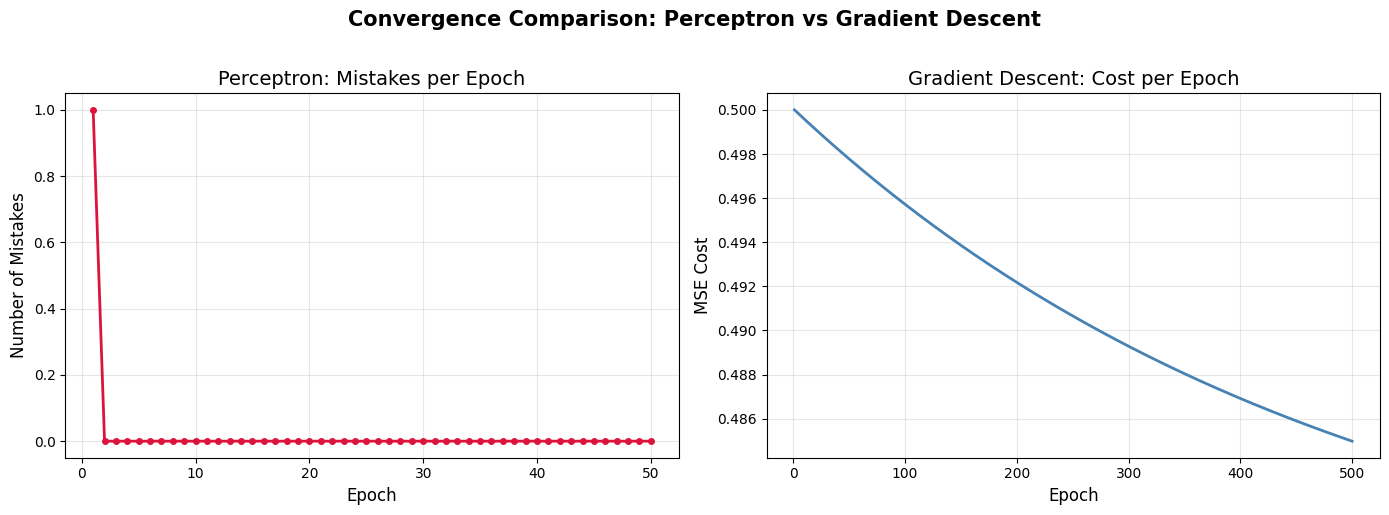

Perceptron  — Initial mistakes:    1  |  Final mistakes:    0
Grad Desc   — Initial cost:    0.5000  |  Final cost:    0.4850


In [14]:
# Train both models first
model_p = WaterPerceptron(lr=0.01, epochs=50)
model_p.fit(X_train, y_train)

model_gd = GDWaterClassifier(lr=0.001, epochs=500)
model_gd.fit(X_train, y_train)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Perceptron Mistakes History ──────────────────────────────────────
axes[0].plot(range(1, len(model_p.mistakes) + 1), model_p.mistakes,
             color='crimson', marker='o', markersize=4, linewidth=2)
axes[0].set_title('Perceptron: Mistakes per Epoch', fontsize=14)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Number of Mistakes', fontsize=12)
axes[0].grid(True, alpha=0.3)

# ── Right: Gradient Descent Cost History ───────────────────────────────────
axes[1].plot(range(1, len(model_gd.cost_history) + 1), model_gd.cost_history,
             color='steelblue', linewidth=2)
axes[1].set_title('Gradient Descent: Cost per Epoch', fontsize=14)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MSE Cost', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Convergence Comparison: Perceptron vs Gradient Descent',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Summary stats ───────────────────────────────────────────────────────────
print(f"Perceptron  — Initial mistakes: {model_p.mistakes[0]:>4d}  |  "
      f"Final mistakes: {model_p.mistakes[-1]:>4d}")
print(f"Grad Desc   — Initial cost:    {model_gd.cost_history[0]:.4f}  |  "
      f"Final cost:    {model_gd.cost_history[-1]:.4f}")

**Convergence Plot Analysis (Task 1)**
- Perceptron mistakes history counts how many samples were misclassified each epoch — this is noisy and jumpy because each weight update is triggered by individual mistakes, so fixing one sample can break another.


- Gradient Descent cost history is smooth because it computes the average MSE over the entire dataset before taking a single step. The global average dampens the noise from any individual sample, so the loss curve descends steadily toward a minimum.

In [15]:
from sklearn.metrics import accuracy_score

# Train all three models
model_p = WaterPerceptron(lr=0.01, epochs=50)
model_p.fit(X_train, y_train)

model_gd = GDWaterClassifier(lr=0.001, epochs=500)
model_gd.fit(X_train, y_train)

model_m = MarginWaterClassifier(lr=0.001, lambda_param=0.01, epochs=500)
model_m.fit(X_train, y_train)

# Compare accuracies
for name, model in [("Perceptron", model_p),
                    ("Gradient Descent", model_gd),
                    ("Margin Classifier", model_m)]:
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{name:20s} → Test Accuracy: {acc*100:.2f}%")

Perceptron           → Test Accuracy: 45.88%
Gradient Descent     → Test Accuracy: 62.80%
Margin Classifier    → Test Accuracy: 62.80%


**Safety Margin (Task 3)**

- For a water sample close to the decision boundary, trust the Margin Classifier. The Perceptron only cares about getting the sign right — its boundary can pass arbitrarily close to training samples.

- The Margin Classifier explicitly enforces a gap of at least 1 unit on either side of the boundary, so a sample near the boundary is still well within the "unsafe" zone before it would ever be classified as potable. In water safety, that buffer is critical.

# Discussion Questions

### Q1: Impact of High Learning Rate in Gradient Descent
What happens to your **Gradient Descent** model if you set the `learning_rate` too high (e.g., `1.0`)?
*Hint: Think about convergence, overshooting, and divergence.*

---

### Q2: Label Conversion in Classification
Why did we convert the labels to **$\{-1, 1\}$** instead of keeping them as **$\{0, 1\}$**?
*Hint: Consider the mathematical formulation of the loss function (e.g., Hinge Loss) and symmetry.*

---

### Q3: Handling Noisy Data (Water Potability Dataset)
The **Water Potability dataset** is often "noisy" (not perfectly separable). Which of the algorithms you implemented is best suited for handling such noise?
*Hint: Think about robustness to outliers and margin-based classifiers.*


**Impact of a High Learning Rate in Gradient Descent**
Setting lr = 1.0 causes divergence. Here's why step by step:

- Each gradient step is meant to move slightly downhill on the loss surface.
- A large lr causes the update w = w - lr * dw to overshoot the minimum — the new weights land on the other side of the valley, at an even higher loss.
- The next step overshoots back again, even further. The cost history instead of decreasing will oscillate or explode toward infinity.

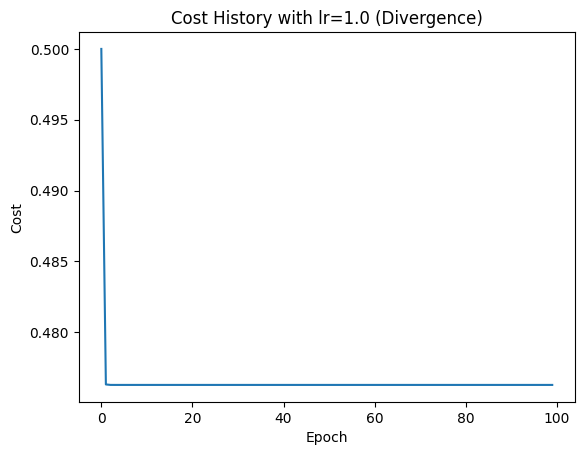

In [16]:
# Demonstrating divergence
model_bad = GDWaterClassifier(lr=1.0, epochs=100)
model_bad.fit(X_train, y_train)

plt.plot(model_bad.cost_history)
plt.title("Cost History with lr=1.0 (Divergence)")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.show()
# You will see the cost spike upward instead of decreasing

The fix is to use a small learning rate (e.g., 0.001) or use a learning rate schedule that reduces lr over time.

**Converting Labels to {-1, +1} Instead of {0, 1}**
Three concrete reasons:
1. *Perceptron update rule requires symmetry:*  The update is w = w + lr * y * x. If y = 0 for the negative class, a misclassified negative sample produces zero update — the model never learns from negative examples. With y = -1, the update correctly pushes the boundary away from negative samples.
2. *Hinge Loss* is mathematically defined around zero.
The hinge loss term is max(0, 1 - y*(w·x + b)). For this to penalize both classes symmetrically around the margin, y must be ±1. With y = 0, the loss for the negative class collapses to max(0, 1) — a constant — giving no useful gradient signal.
3. *Decision boundary symmetry:*
np.sign(score) returns -1, 0, or +1. If your true labels are {0, 1} but predictions are {-1, +1}, every accuracy calculation will be wrong. Using {-1, +1} throughout keeps the math and evaluation consistent.

**Best Algorithm for Noisy Data (Water Potability)**
The Margin Classifier (SVM-style with Hinge Loss + L2 Regularization) is best suited for noisy, non-separable data. Here's why each algorithm compares:


|Algorithm|Behavior on Noisy Data|
|:---------|:-------------------------------|
|Perceptron|Never converges if data isn't linearly separable — keeps cycling through mistakes indefinitely|
|Gradient Descent (MSE)|Converges but MSE is sensitive to outliers since squaring errors amplifies their effect|
|Margin Classifier|Hinge loss ignores correctly-classified points beyond the margin, so outliers on the correct side don't distort the boundary|


- The L2 regularization term (λ‖w‖²) is especially important for noisy data — it prevents the model from fitting to individual noisy samples by penalizing large weights, which would overfit. The lambda_param controls this trade-off: a higher value means a wider, more robust margin at the cost of some training accuracy.


- In water safety specifically, the cost of a false negative (classifying unsafe water as potable) is far higher than a false positive. The margin classifier's built-in safety gap directly addresses this by being conservative near the decision boundary — exactly what you want when human health is at stake